In [100]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [101]:
task = "Task"
shovel = "Shovel"
cube = "Cube"

condition = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

factor_device = "Device"
device_proxy = "P"
device_controller = "C"

factor_scaling = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"

subject = "Subject"

In [102]:
borg_cr = "How physically challenging was the experience?"
sp_fatigue = "How fatigued where you after the experience?"

general_1 = "I felt the weight of the object, while i was grabbing it"
general_2 = "The weight of the object, while i was grabbing it, felt realistic"
general_custom = [general_1, general_2]

shovel_1 = "I felt the weight of the shovel increasing when loading it"
shovel_2 = "I felt the weight of the shovel decreasing when unloading it"
shovel_3 = "After the shovel had been loaded, it required more effort to manipulate"
shovel_4 = "After the shovel had been unloaded, it required less effort to manipulate"
shovel_custom = [shovel_1, shovel_2, shovel_3, shovel_4]

fps_1 = "  My sense of being in the virtual world was like being in a real place."
fps_2 = "During the experience, I felt the virtual world was reality for me. "
fps_3 = "I felt like I was actually there in the virtual world. "
fps_4 = "I felt present in the virtual world. "
fps_5 = "I felt I could control my actions within the virtual world. "
fps_6 = "I felt the virtual world was responsive to my actions. "
fps_7 = "I felt I could move or manipulate objects easily in the virtual world. "
fps_8 = "I felt involved in the virtual world experience. "
fps_9 = "I could concentrate on the virtual activities rather than the controls to perform them. "
fps_10 = "When something happened to my virtual body, I felt it happened to my real body. "
fps = [fps_1, fps_2, fps_3, fps_4, fps_5, fps_6, fps_7, fps_8, fps_9, fps_10]

relevant_keys = [condition, task, borg_cr, sp_fatigue] + general_custom + shovel_custom + fps

In [103]:
def get_df(name):
    path = './questionnaires/' + name + '.csv'
    return pd.read_csv(path)

In [104]:
data = get_df('experiments').filter(items=relevant_keys)

data[factor_device] = data[condition].str[0]
data[factor_scaling] = data[condition].str[1:]

data.insert(0, 'No', range(0, 0 + len(data)))
data[subject] = data.apply(lambda x: int(x['No'] / 12) + 1, axis=1)

data.tail(3)

,No,Condition,Task,How physically challenging was the experience?,How fatigued where you after the experience?,"I felt the weight of the object, while i was grabbing it","The weight of the object, while i was grabbing it, felt realistic",I felt the weight of the shovel increasing when loading it,I felt the weight of the shovel decreasing when unloading it,"After the shovel had been loaded, it required more effort to manipulate",...,I felt present in the virtual world.,I felt I could control my actions within the virtual world.,I felt the virtual world was responsive to my actions.,I felt I could move or manipulate objects easily in the virtual world.,I felt involved in the virtual world experience.,I could concentrate on the virtual activities rather than the controls to perform them.,"When something happened to my virtual body, I felt it happened to my real body.",Device,Scaling,Subject
501,501,C1,Shovel,1 - Very light,1 - Very alert and fully awake,2,1,1.0,1.0,2.0,...,5,5,5,3,4,3,3,C,1,42
502,502,C2,Shovel,1 - Very light,1 - Very alert and fully awake,3,1,1.0,1.0,1.0,...,5,4,5,3,4,2,3,C,2,42
503,503,P2,Shovel,1 - Very light,1 - Very alert and fully awake,7,7,2.0,2.0,2.0,...,5,5,3,6,4,7,3,P,2,42


In [105]:
def plot_experiment(df, e, key, title, scale):
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    task_df = df[df[task] == e]
    values = list(map(lambda x: task_df[task_df[condition] == x][key], conditions))
    means = list(map(lambda x: np.mean(x), values))

    axs[0].bar(conditions, means, color=colors)
    axs[0].set_title('[' + e + '] Mean ' + title)
    axs[0].set_ylim(scale)

    axs[1].violinplot(values, showmeans=True)
    axs[1].set_title('[' + e + '] ' + title)
    axs[1].set_ylim([scale[0]-0.5, scale[1]+0.5])
    axs[1].set_xticks([y + 1 for y in range(len(conditions))], labels=conditions)

    axs[2].boxplot(values, tick_labels=conditions)
    axs[2].set_title('[' + e + '] ' + title)
    axs[2].set_ylabel([scale[0]-0.5, scale[1]+0.5])

    plt.show()

In [106]:
def two_way_repeated_measures_anova(df, e, key):
    task_df = df[df[task] == e]

    result = pg.rm_anova(
        dv=key,
        within=[factor_device, factor_scaling],
        subject=subject,
        data=task_df,
        detailed=True
    )

    p_key = "p-GG-corr"
    result["Significance (p<0.05)"] = result.apply(lambda x: "✅" if x[p_key] < 0.05 else ("🟨"  if x[p_key] < 0.1 else "❌"), axis=1)

    display(result)

    # posthocs = pg.pairwise_ttests(
    # dv=key,
    # within=[factor_device, factor_scaling],
    # subject=subject,
    # data=df,
    # padjust='bonf'
    # )

    # display(posthocs)

In [107]:
def report_exeriment(df, e, key, title, scale):
    print('\033[1m' + "------ " + "["+e+"] " + title + ":"  + " ------")
    two_way_repeated_measures_anova(df, e, key)
    plot_experiment(df, e, key, title, scale)

------ [Cube] FPS Total Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,4.426825,1,41,4.426825,14.084486,0.000542,0.000542,0.022965,1.000000,✅
1,Scaling,1.721667,2,82,0.860833,7.364458,0.001144,0.001338,0.009059,0.963042,✅
2,Device * Scaling,0.183889,2,82,0.091944,0.886704,0.415925,0.407850,0.000975,0.912055,❌


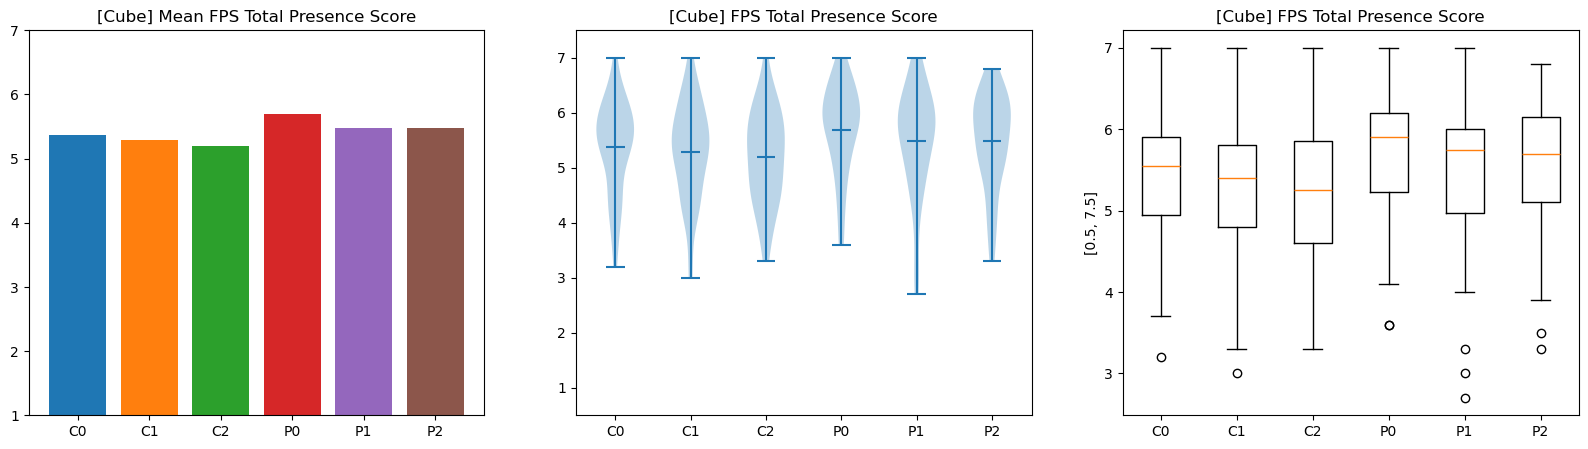

------ [Shovel] FPS Total Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,8.000040,1,41,8.000040,13.310875,0.000738,0.000738,0.041843,1.000000,✅
1,Scaling,4.818810,2,82,2.409405,9.571696,0.000184,0.000446,0.025631,0.849113,✅
2,Device * Scaling,0.341032,2,82,0.170516,0.758576,0.471591,0.471565,0.001858,0.999785,❌


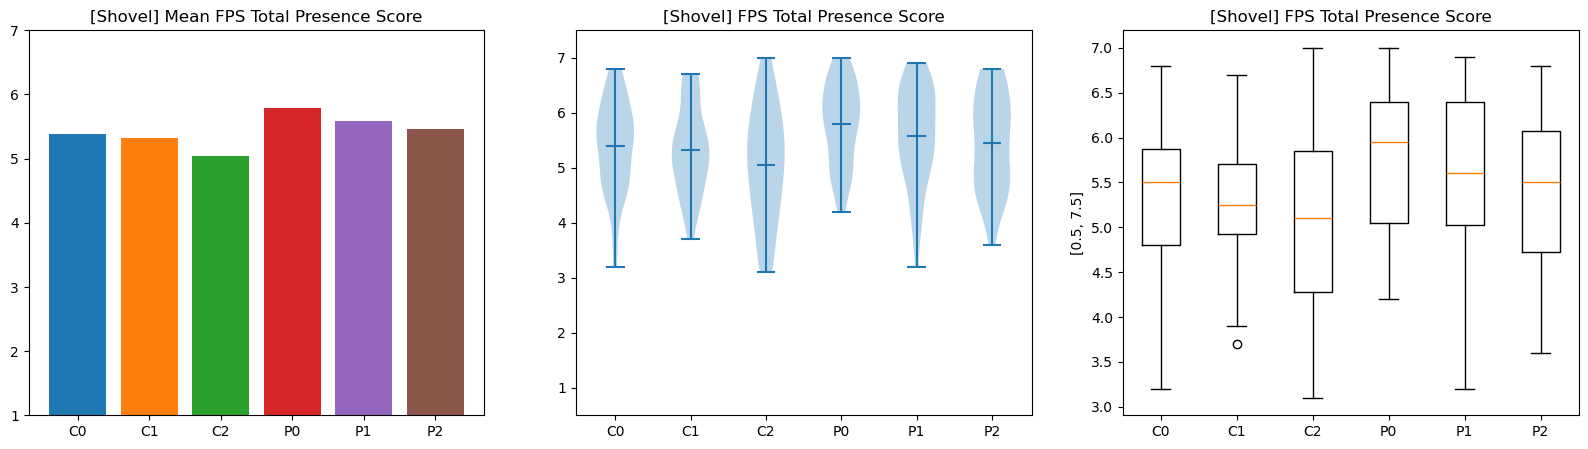

In [108]:
fps_total = 'fps_total'
#Total Presence Score: (FPS1-10) / 10
data[fps_total] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9] + x[fps_10]) / 10,
    axis = 1)

title = 'FPS Total Presence Score'
score = fps_total
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Interaction Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,3.055804,1,41,3.055804,9.148981,0.004282,0.004282,0.017454,1.000000,✅
1,Scaling,2.226314,2,82,1.113157,8.588649,0.000411,0.000470,0.012777,0.973888,✅
2,Device * Scaling,0.091890,2,82,0.045945,0.444771,0.642508,0.611625,0.000534,0.853719,❌


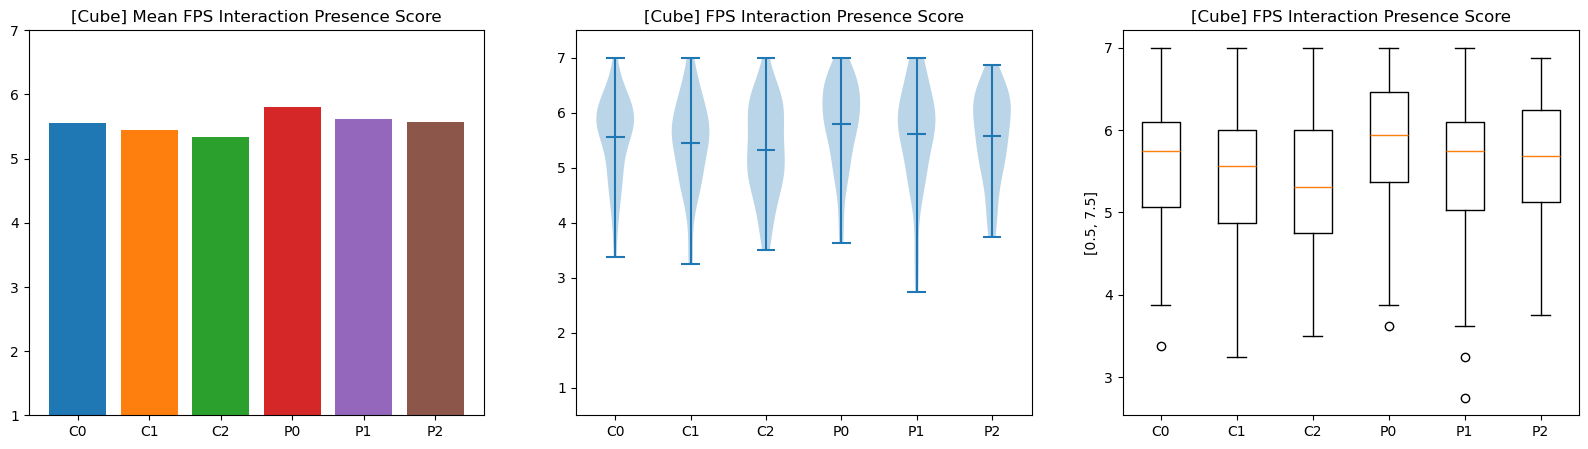

------ [Shovel] FPS Interaction Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,8.580357,1,41,8.580357,13.458924,0.000696,0.000696,0.044863,1.000000,✅
1,Scaling,5.972594,2,82,2.986297,9.577053,0.000183,0.000479,0.031660,0.836687,✅
2,Device * Scaling,0.368676,2,82,0.184338,0.738249,0.481100,0.480730,0.002014,0.997010,❌


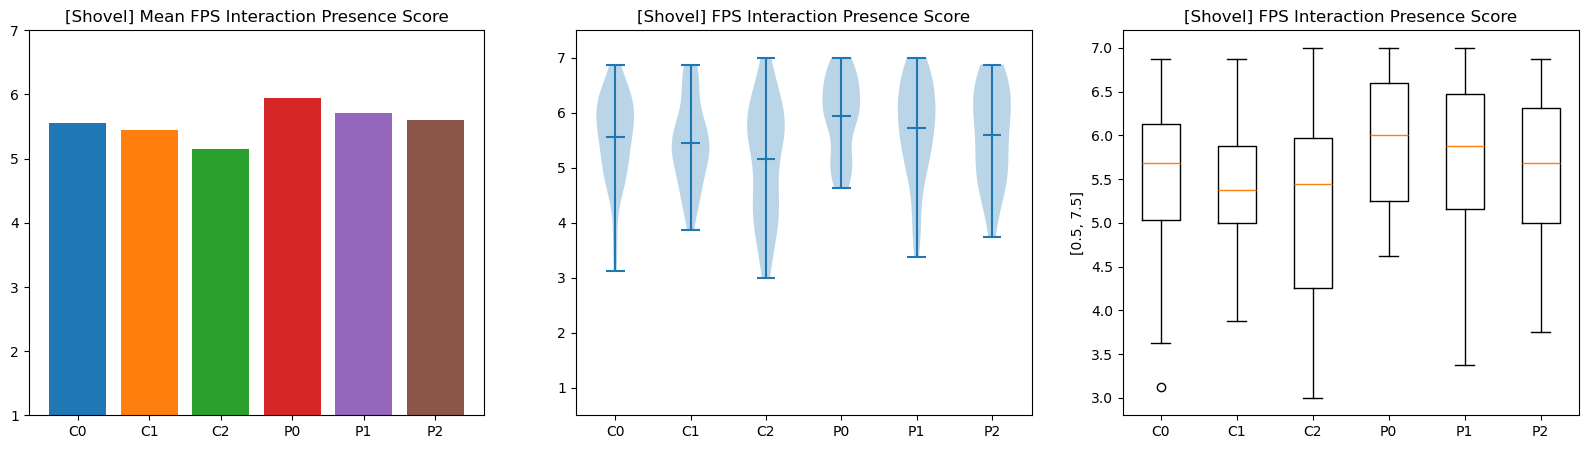

In [109]:
fps_interaction = 'fps_interaction'
#Interaction Presence Score: (FPS-1 + FPS-2 + FPS-4 + FPS-5 + FPS-6 + FPS-7 + FPS-8 + FPS-9) / 8
data[fps_interaction] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9]) / 8,
    axis = 1)

title = 'FPS Interaction Presence Score'
score = fps_interaction
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Scenario Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,2.682540,1,41,2.682540,4.395644,0.042243,0.042243,0.007872,1.000000,✅
1,Scaling,1.006173,2,82,0.503086,2.167694,0.120955,0.126884,0.002967,0.896207,❌
2,Device * Scaling,0.050265,2,82,0.025132,0.183251,0.832899,0.789457,0.000149,0.819015,❌


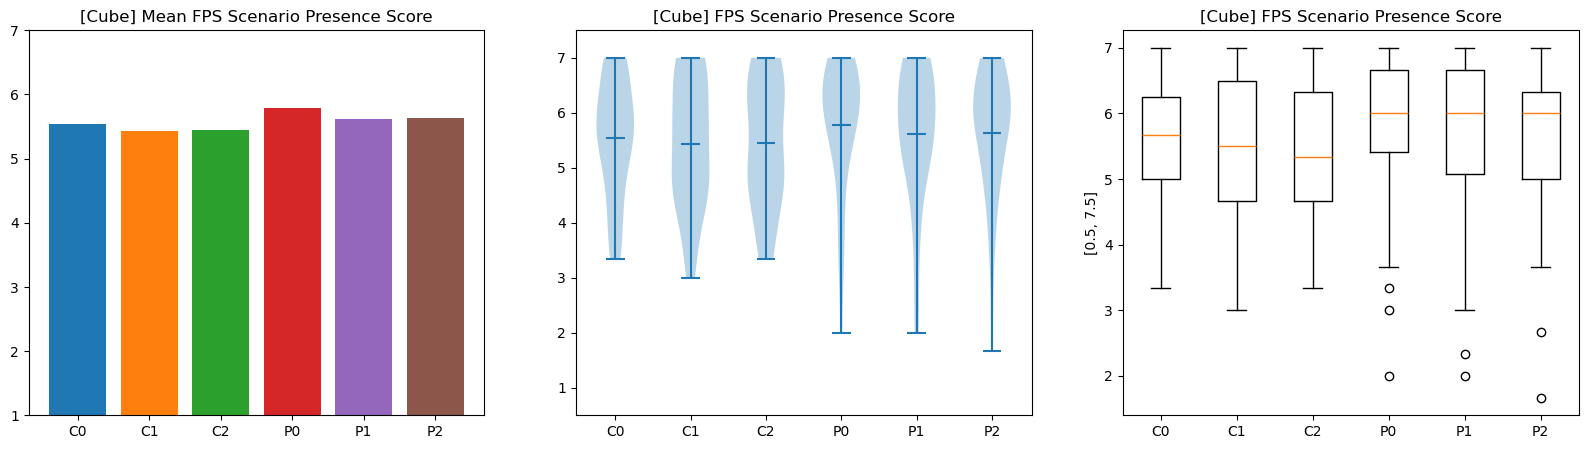

------ [Shovel] FPS Scenario Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,5.432540,1,41,5.432540,7.956670,0.007351,0.007351,0.021698,1.000000,✅
1,Scaling,1.597884,2,82,0.798942,3.288712,0.042279,0.047499,0.006481,0.904702,✅
2,Device * Scaling,0.137566,2,82,0.068783,0.337449,0.714575,0.695876,0.000561,0.916398,❌


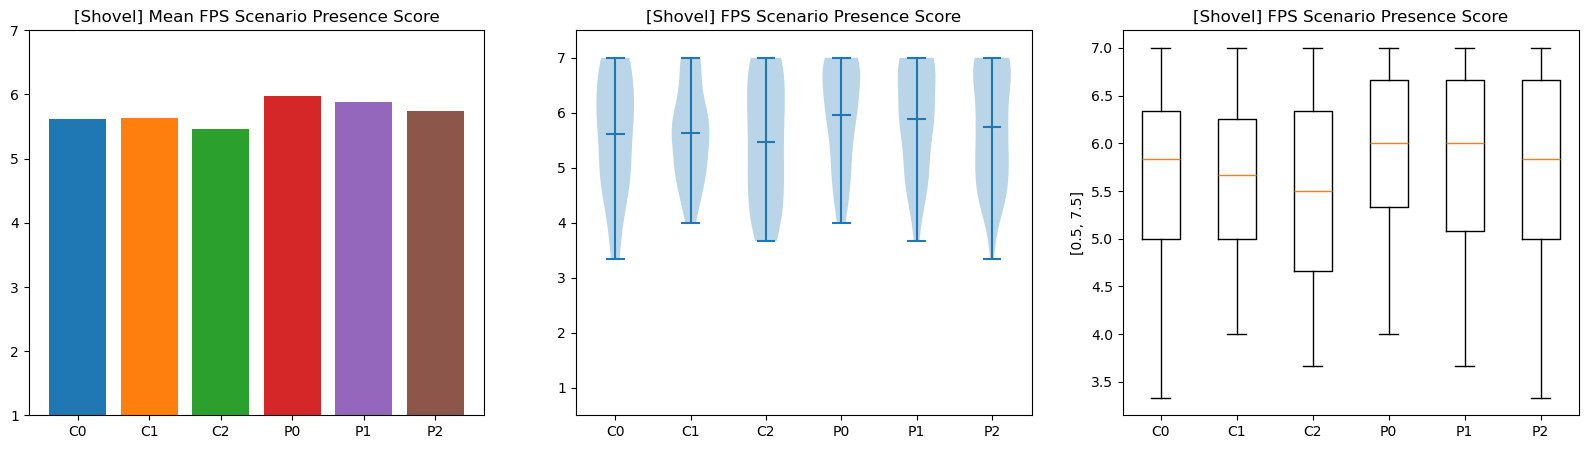

In [110]:
fps_scenario = 'fps_scenario'
#Scenario Presence Score: (FPS-3 + FPS-4 + FPS-8) / 3
data[fps_scenario] = data.apply(lambda x: 
    (x[fps_3] + x[fps_4] + x[fps_8]) / 3,
    axis = 1)

title = 'FPS Scenario Presence Score'
score = fps_scenario
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] FPS Display Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,4.587302,1,41,4.587302,12.982157,0.000843,0.000843,0.018135,1.000000,✅
1,Scaling,0.952543,2,82,0.476271,3.066800,0.051948,0.056541,0.003821,0.920506,🟨
2,Device * Scaling,0.255750,2,82,0.127875,0.900140,0.410491,0.401181,0.001029,0.896042,❌


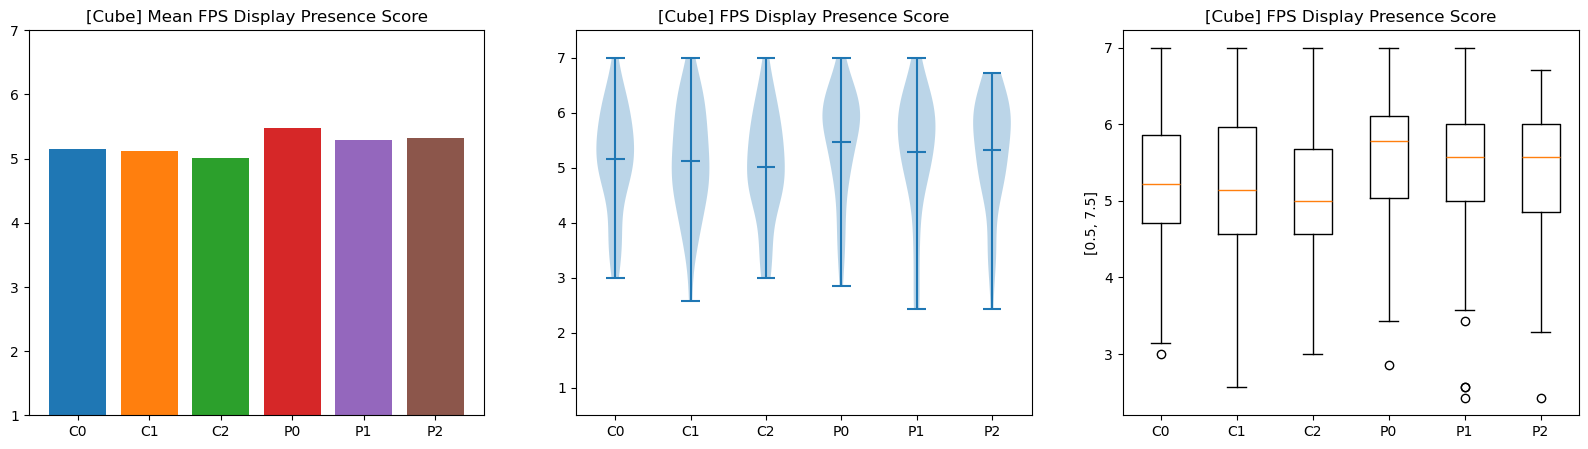

------ [Shovel] FPS Display Presence Score: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,5.773324,1,41,5.773324,9.517922,0.003636,0.003636,0.027364,1.000000,✅
1,Scaling,2.429057,2,82,1.214529,6.245894,0.002987,0.004845,0.011698,0.857978,✅
2,Device * Scaling,0.275510,2,82,0.137755,0.780127,0.461719,0.460377,0.001341,0.988165,❌


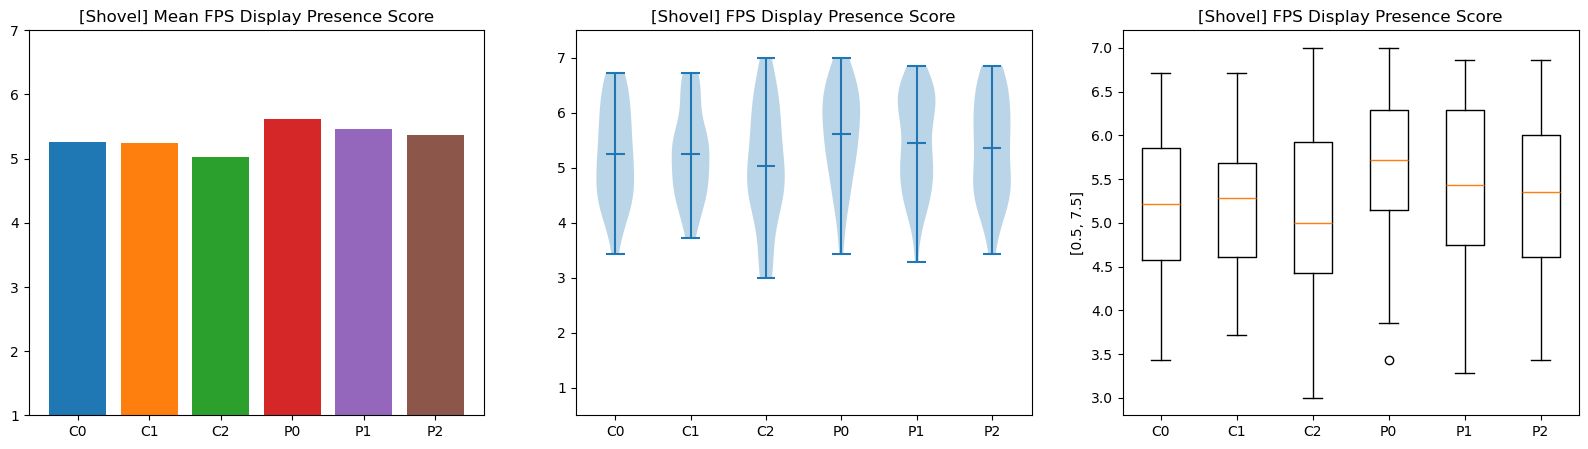

In [111]:
fps_display = 'fps_display'
#Display Presence Score: (FPS-1 + FPS-2 + FPS-3 + FPS-4 +FPS-7 +FPS-8 + FPS-10) / 7
data[fps_display] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_7] + x[fps_8] + x[fps_10]) / 7,
    axis = 1)

title = 'FPS Display Presence Score'
score = fps_display
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Borg Challenge Rating (CR10): ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,4.063492,1,41,4.063492,18.642984,0.000097,0.000097,0.027312,1.000000,✅
1,Scaling,0.341270,2,82,0.170635,0.933298,0.397391,0.391804,0.002353,0.930110,❌
2,Device * Scaling,0.293651,2,82,0.146825,0.878402,0.419319,0.408023,0.002025,0.881868,❌


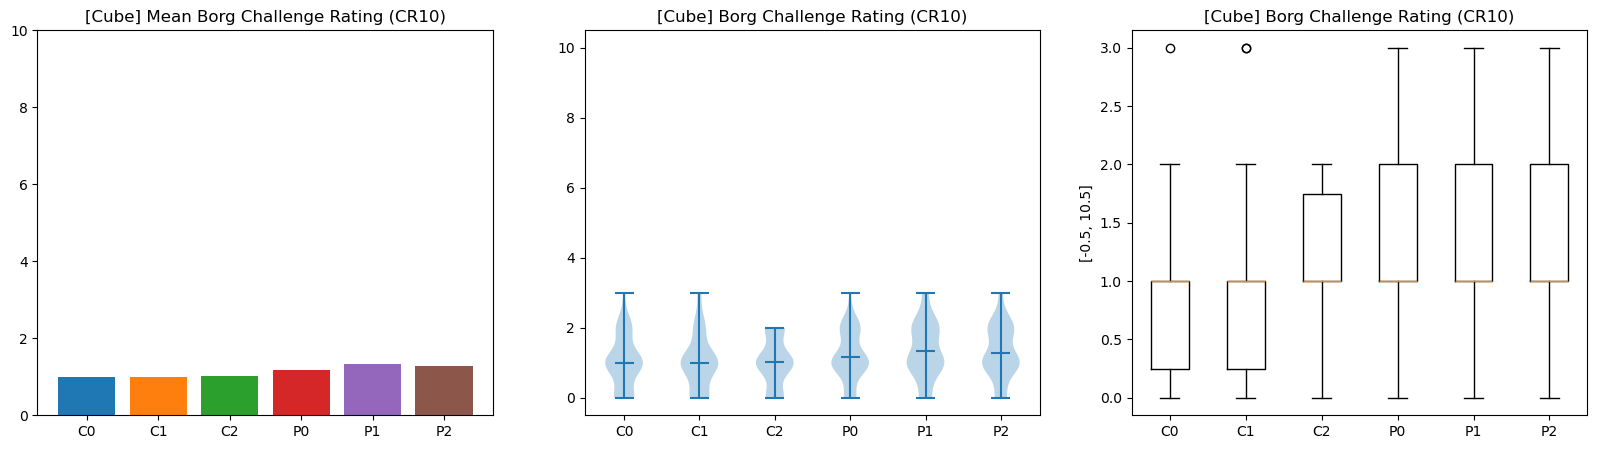

------ [Shovel] Borg Challenge Rating (CR10): ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,7.337302,1,41,7.337302,26.949520,0.000006,0.000006,0.028797,1.000000,✅
1,Scaling,0.722222,2,82,0.361111,1.460274,0.238146,0.239129,0.002910,0.899140,❌
2,Device * Scaling,0.150794,2,82,0.075397,0.481161,0.619799,0.603025,0.000609,0.914342,❌


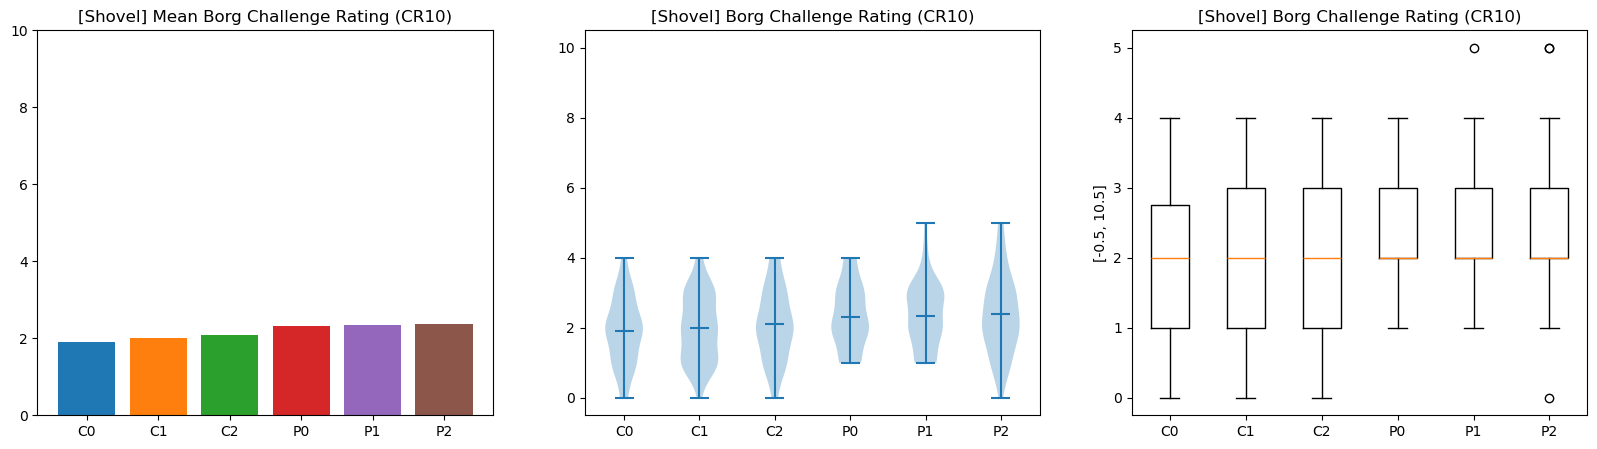

In [112]:
borg_cr_numeric = 'borg_cr_numeric'
#Format: X(X) - ...
data[borg_cr_numeric] = data.apply(lambda x: int(x[borg_cr].split()[0]), axis = 1)

title = 'Borg Challenge Rating (CR10)'
score = borg_cr_numeric
scale = [0,10]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Samn-Perelli Fatigue Level: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,1.146825,1,41,1.146825,8.783543,0.005044,0.005044,0.007598,1.000000,✅
1,Scaling,0.293651,2,82,0.146825,0.878402,0.419319,0.386302,0.001957,0.697315,❌
2,Device * Scaling,0.341270,2,82,0.170635,1.448644,0.240836,0.241104,0.002273,0.686872,❌


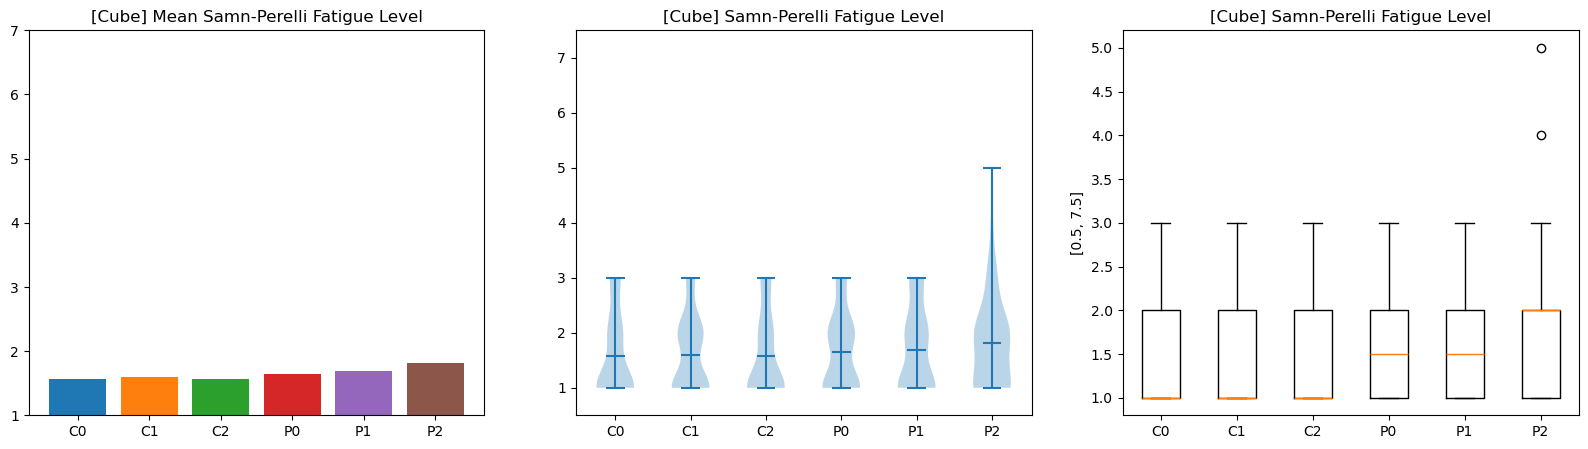

------ [Shovel] Samn-Perelli Fatigue Level: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,2.892857,1,41,2.892857,9.165593,0.004251,0.004251,0.009330,1.000000,✅
1,Scaling,1.960317,2,82,0.980159,4.221342,0.017991,0.023958,0.006341,0.848962,✅
2,Device * Scaling,0.500000,2,82,0.250000,1.069565,0.347896,0.338439,0.001625,0.830403,❌


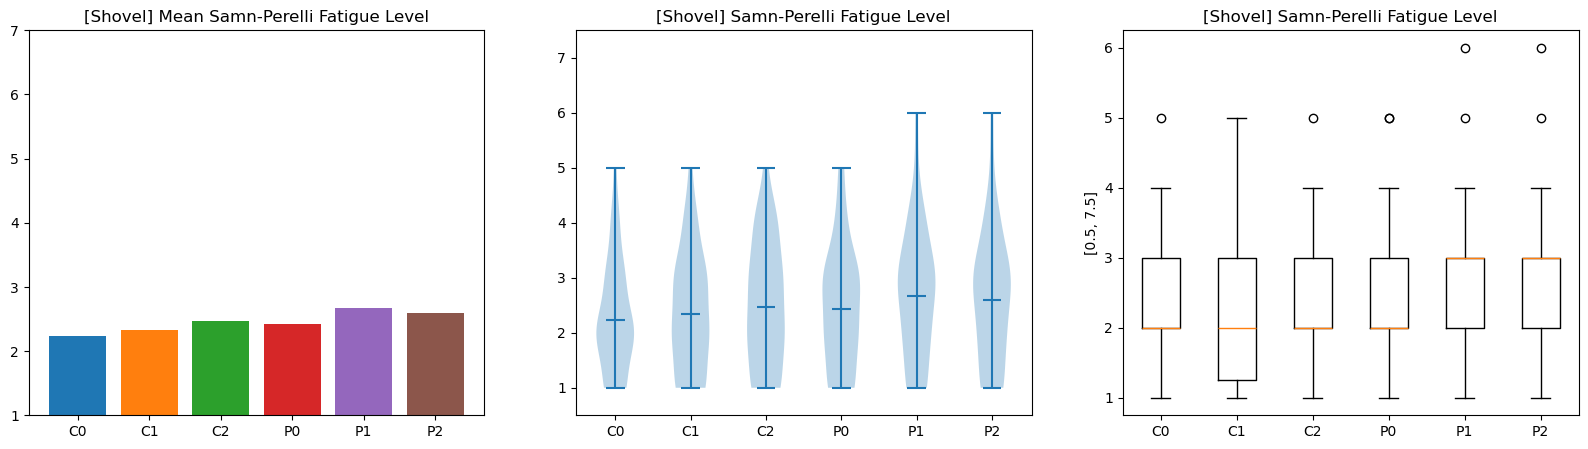

In [113]:
sp_fatigue_numeric = 'sp_fatigue_numeric'
#Format: X - ...
data[sp_fatigue_numeric] = data.apply(lambda x: int(x[sp_fatigue].split()[0]), axis = 1)

title = 'Samn-Perelli Fatigue Level'
score = sp_fatigue_numeric
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Perceived Weight: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,761.285714,1,41,761.285714,178.650041,1.556154e-16,1.556154e-16,0.599438,1.000000,✅
1,Scaling,0.000000,2,82,0.000000,0.000000,1.000000e+00,1.000000e+00,0.000000,0.965876,❌
2,Device * Scaling,0.857143,2,82,0.428571,0.584323,5.597873e-01,5.290503e-01,0.001682,0.827061,❌


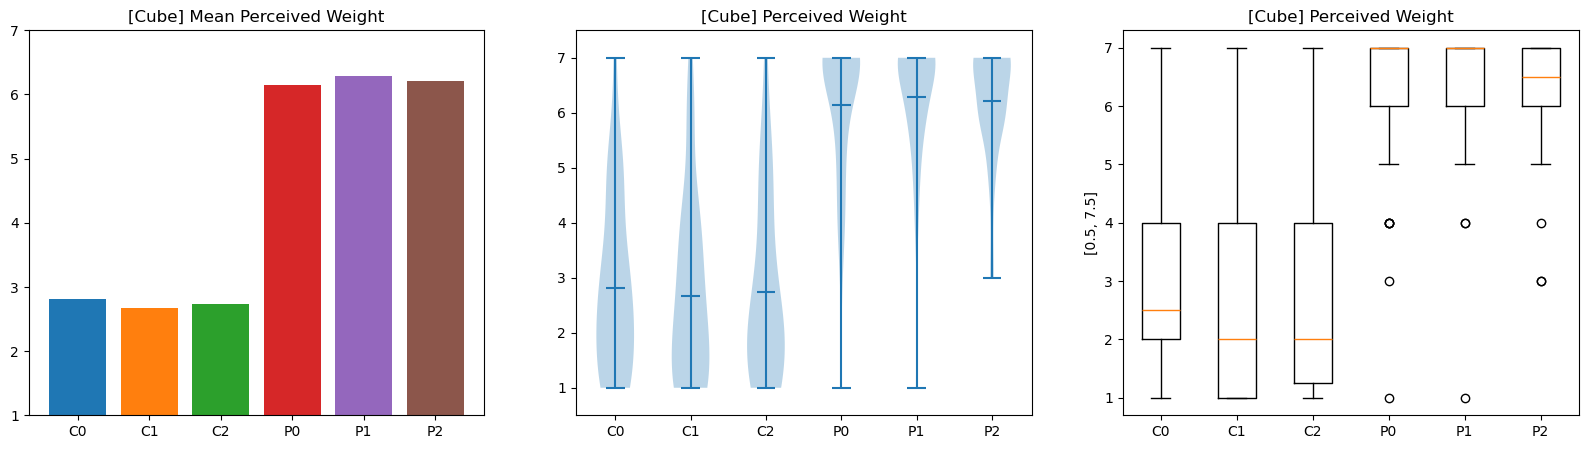

------ [Shovel] Perceived Weight: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,582.099206,1,41,582.099206,100.389741,1.385897e-12,1.385897e-12,0.457581,1.00000,✅
1,Scaling,1.579365,2,82,0.789683,1.182635,3.116421e-01,2.988463e-01,0.002284,0.69193,❌
2,Device * Scaling,0.150794,2,82,0.075397,0.107493,8.982094e-01,8.568303e-01,0.000218,0.80601,❌


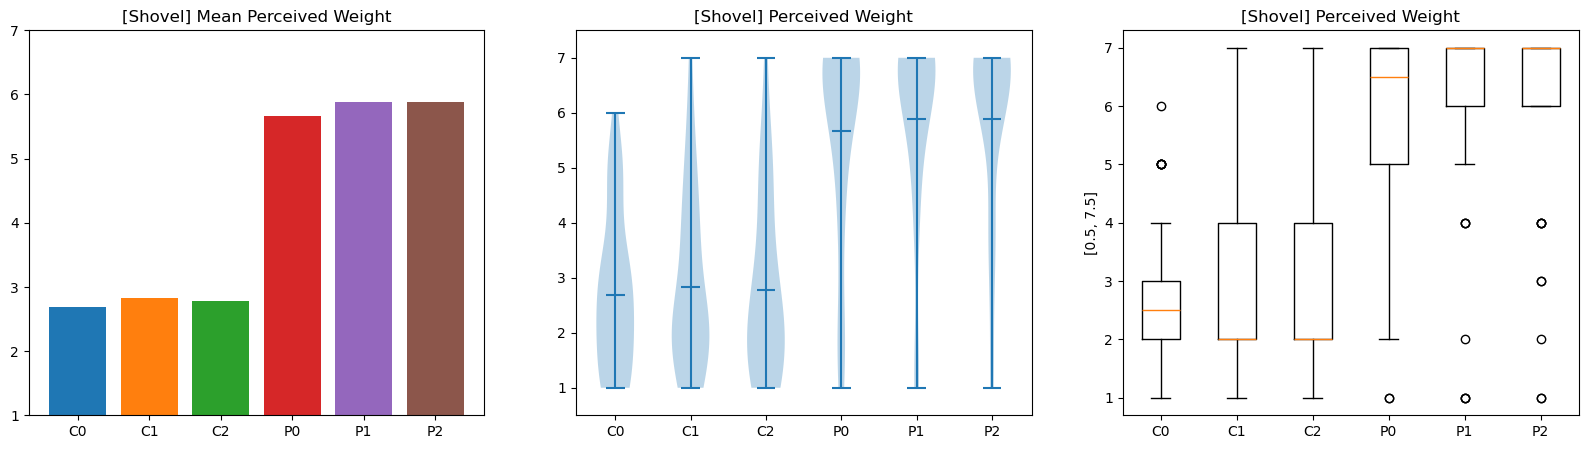

In [114]:
general_perceived_weight = 'general_perceived_weight'
data[general_perceived_weight] = data[general_1]

title = 'Perceived Weight'
score = general_perceived_weight
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Cube] Perceived Weight Realism: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,700.000000,1,41,700.000000,188.402626,6.357494e-17,6.357494e-17,0.561069,1.000000,✅
1,Scaling,0.023810,2,82,0.011905,0.011908,9.881641e-01,9.854520e-01,0.000043,0.946549,❌
2,Device * Scaling,0.071429,2,82,0.035714,0.042694,9.582263e-01,9.522768e-01,0.000130,0.948907,❌


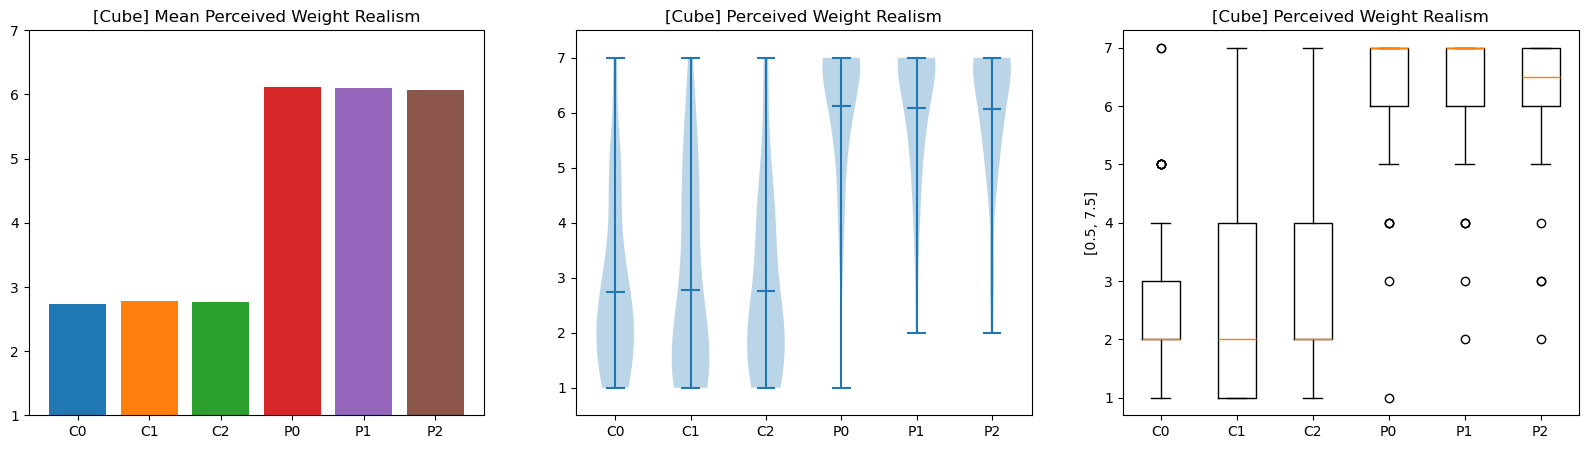

------ [Shovel] Perceived Weight Realism: ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,609.777778,1,41,609.777778,109.227184,3.954738e-13,3.954738e-13,0.475551,1.000000,✅
1,Scaling,2.214286,2,82,1.107143,1.501772,2.287965e-01,2.311220e-01,0.003282,0.805989,❌
2,Device * Scaling,0.388889,2,82,0.194444,0.261623,7.704416e-01,7.702826e-01,0.000578,0.999269,❌


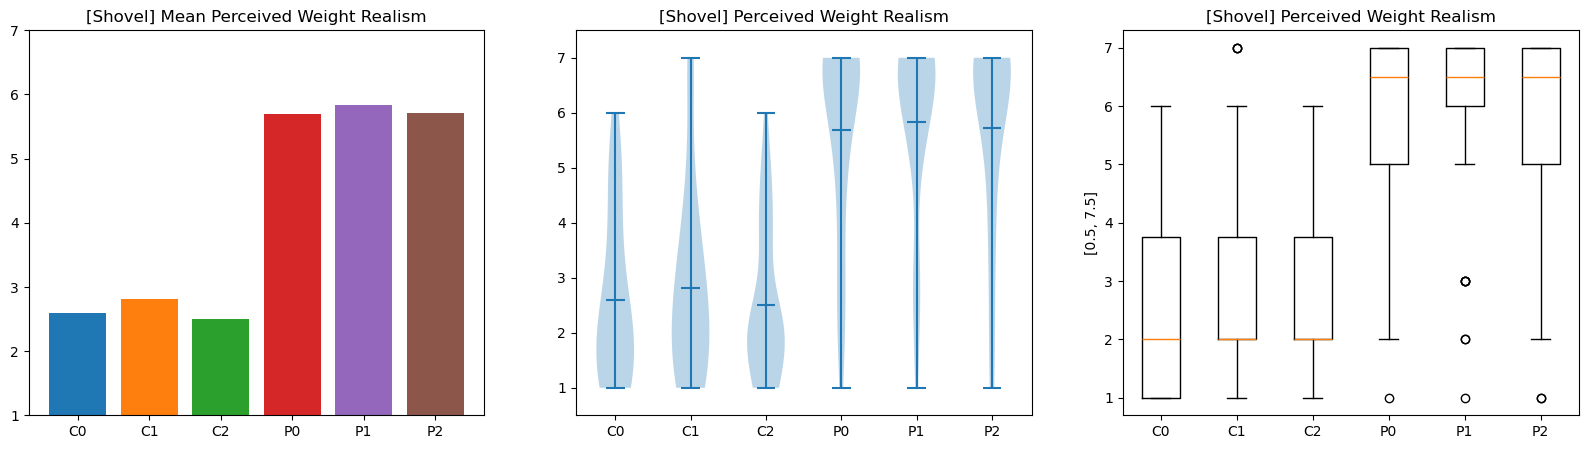

In [115]:
general_perceived_weight_realism = 'general_perceived_weight_realism'
data[general_perceived_weight_realism] = data[general_2]

title = 'Perceived Weight Realism'
score = general_perceived_weight_realism
scale = [1,7]
report_exeriment(data, cube, score, title,scale)
report_exeriment(data, shovel, score, title, scale)

------ [Shovel] Perceived weight increase (Load): ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,0.194444,1,41,0.194444,0.116714,0.734371,0.734371,0.000319,1.000000,❌
1,Scaling,6.380952,2,82,3.190476,5.380999,0.006371,0.013779,0.010375,0.720851,✅
2,Device * Scaling,2.031746,2,82,1.015873,1.773572,0.176174,0.180247,0.003327,0.895166,❌


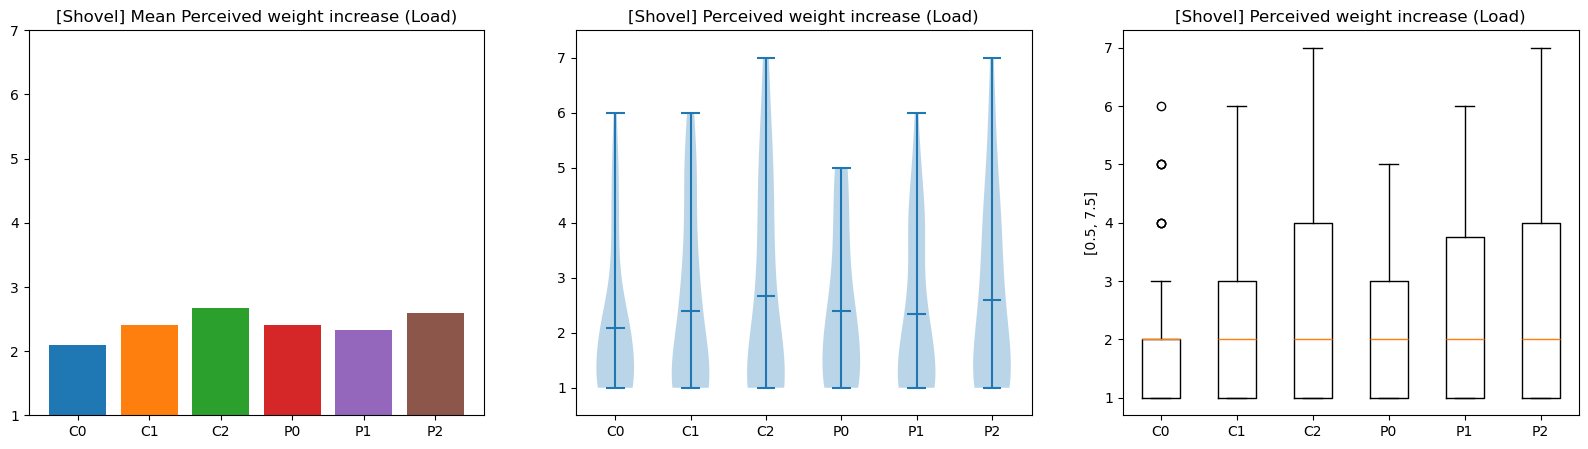

------ [Shovel] Perceived weight decrease (Unload): ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,0.015873,1,41,0.015873,0.011625,0.914666,0.914666,0.000027,1.000000,❌
1,Scaling,5.484127,2,82,2.742063,4.799424,0.010688,0.016689,0.009276,0.808341,✅
2,Device * Scaling,1.388889,2,82,0.694444,1.023976,0.363710,0.360663,0.002366,0.948589,❌


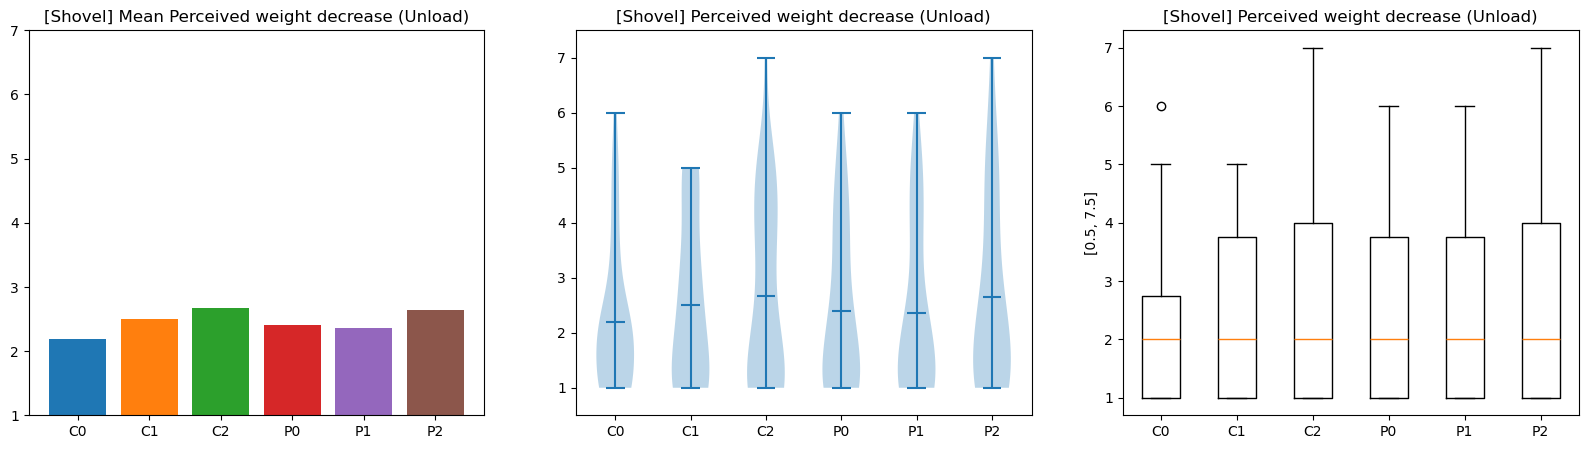

------ [Shovel] Perceived effort increase (Load): ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,1.587302,1,41,1.587302,0.637537,0.429205,0.429205,0.002037,1.000000,❌
1,Scaling,22.952381,2,82,11.476190,7.926996,0.000712,0.001336,0.028665,0.865239,✅
2,Device * Scaling,0.412698,2,82,0.206349,0.188173,0.828828,0.802026,0.000530,0.882883,❌


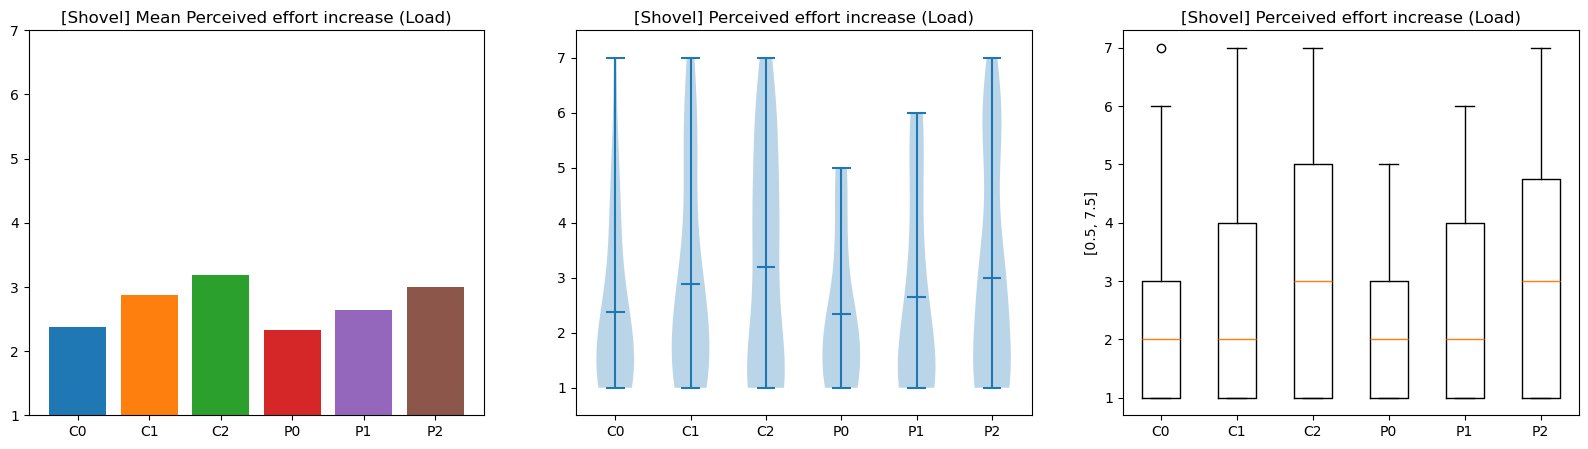

------ [Shovel] Perceived effort decrease (Unload): ------


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance (p<0.05)
0,Device,3.571429,1,41,3.571429,1.380162,0.246852,0.246852,0.005260,1.000000,❌
1,Scaling,20.023810,2,82,10.011905,7.182045,0.001336,0.003462,0.028794,0.768635,✅
2,Device * Scaling,0.880952,2,82,0.440476,0.432810,0.650157,0.639074,0.001303,0.945531,❌


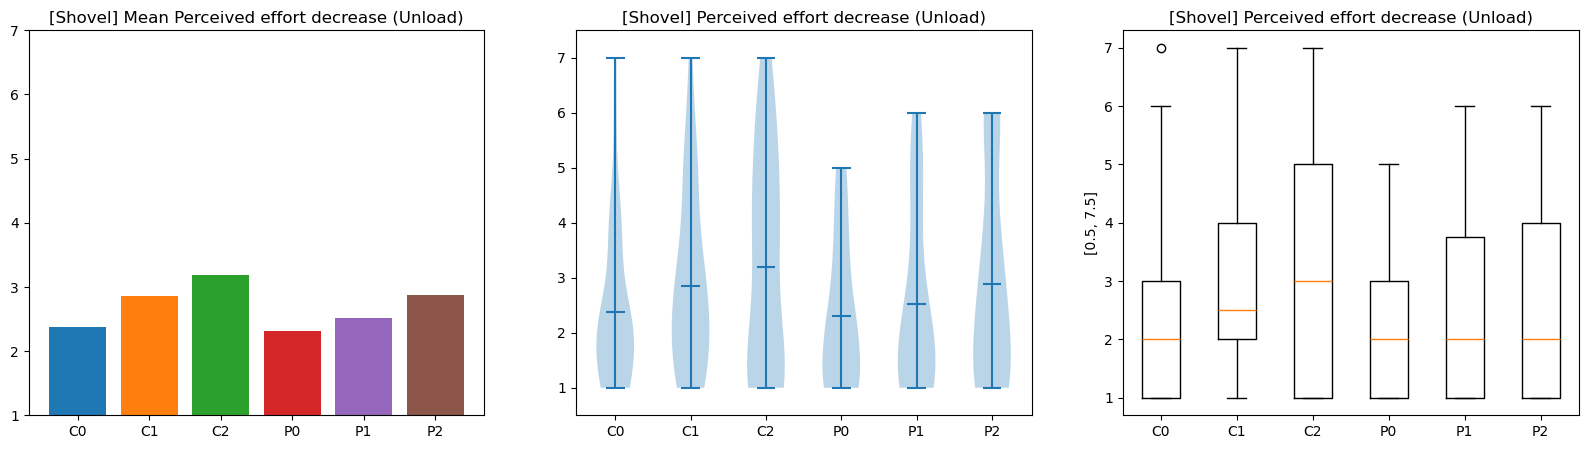

In [116]:
scale = [1,7]

shovel_load_weight = 'shovel_load_weight'
data[shovel_load_weight] = data[shovel_1]
report_exeriment(data, shovel, shovel_load_weight, 'Perceived weight increase (Load)', scale)

shovel_unload_weight = 'shovel_unload_weight'
data[shovel_unload_weight] = data[shovel_2]
report_exeriment(data, shovel, shovel_unload_weight, 'Perceived weight decrease (Unload)', scale)

shovel_load_effort = 'shovel_load_effort'
data[shovel_load_effort] = data[shovel_3]
report_exeriment(data, shovel, shovel_load_effort, 'Perceived effort increase (Load)', scale)

shovel_unload_effort = 'shovel_unload_effort'
data[shovel_unload_effort] = data[shovel_4]
report_exeriment(data, shovel, shovel_unload_effort, 'Perceived effort decrease (Unload)', scale)